In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("parsed_save2.csv")

In [7]:
data.head()

,Unnamed: 0,hero_r1,hero_r2,stage_pre,stage_flop,stage_turn,stage_river,board_r1,board_r2,board_r3,board_r4,board_r5,suit_po,stra_po,gut_po,position_norm,facing_ratio,if_fold,hero_bet_ratio,result
0,0,0.357,0.5,1,0,0,0,0.0,0.000,0.000,0.000,0.000,0.2,0.2,0,0.167,0.667,0,1.333,0.175
1,1,0.357,0.5,0,1,0,0,0.5,0.286,0.429,0.000,0.000,0.4,0.8,0,0.167,0.000,0,0.571,0.175
2,2,0.357,0.5,0,0,1,0,0.5,0.286,0.429,0.929,0.000,0.4,0.8,0,0.167,0.000,0,0.000,0.175
3,3,0.357,0.5,0,0,1,0,0.5,0.286,0.429,0.929,0.000,0.4,0.8,0,0.167,0.400,0,0.400,0.175
4,4,0.357,0.5,0,0,0,1,0.5,0.286,0.429,0.929,0.786,0.4,0.8,0,0.167,0.000,0,0.514,0.175


In [17]:
data.columns

Index(['Unnamed: 0', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop',
       'stage_turn', 'stage_river', 'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'if_fold', 'hero_bet_ratio', 'result'],
      dtype='str')

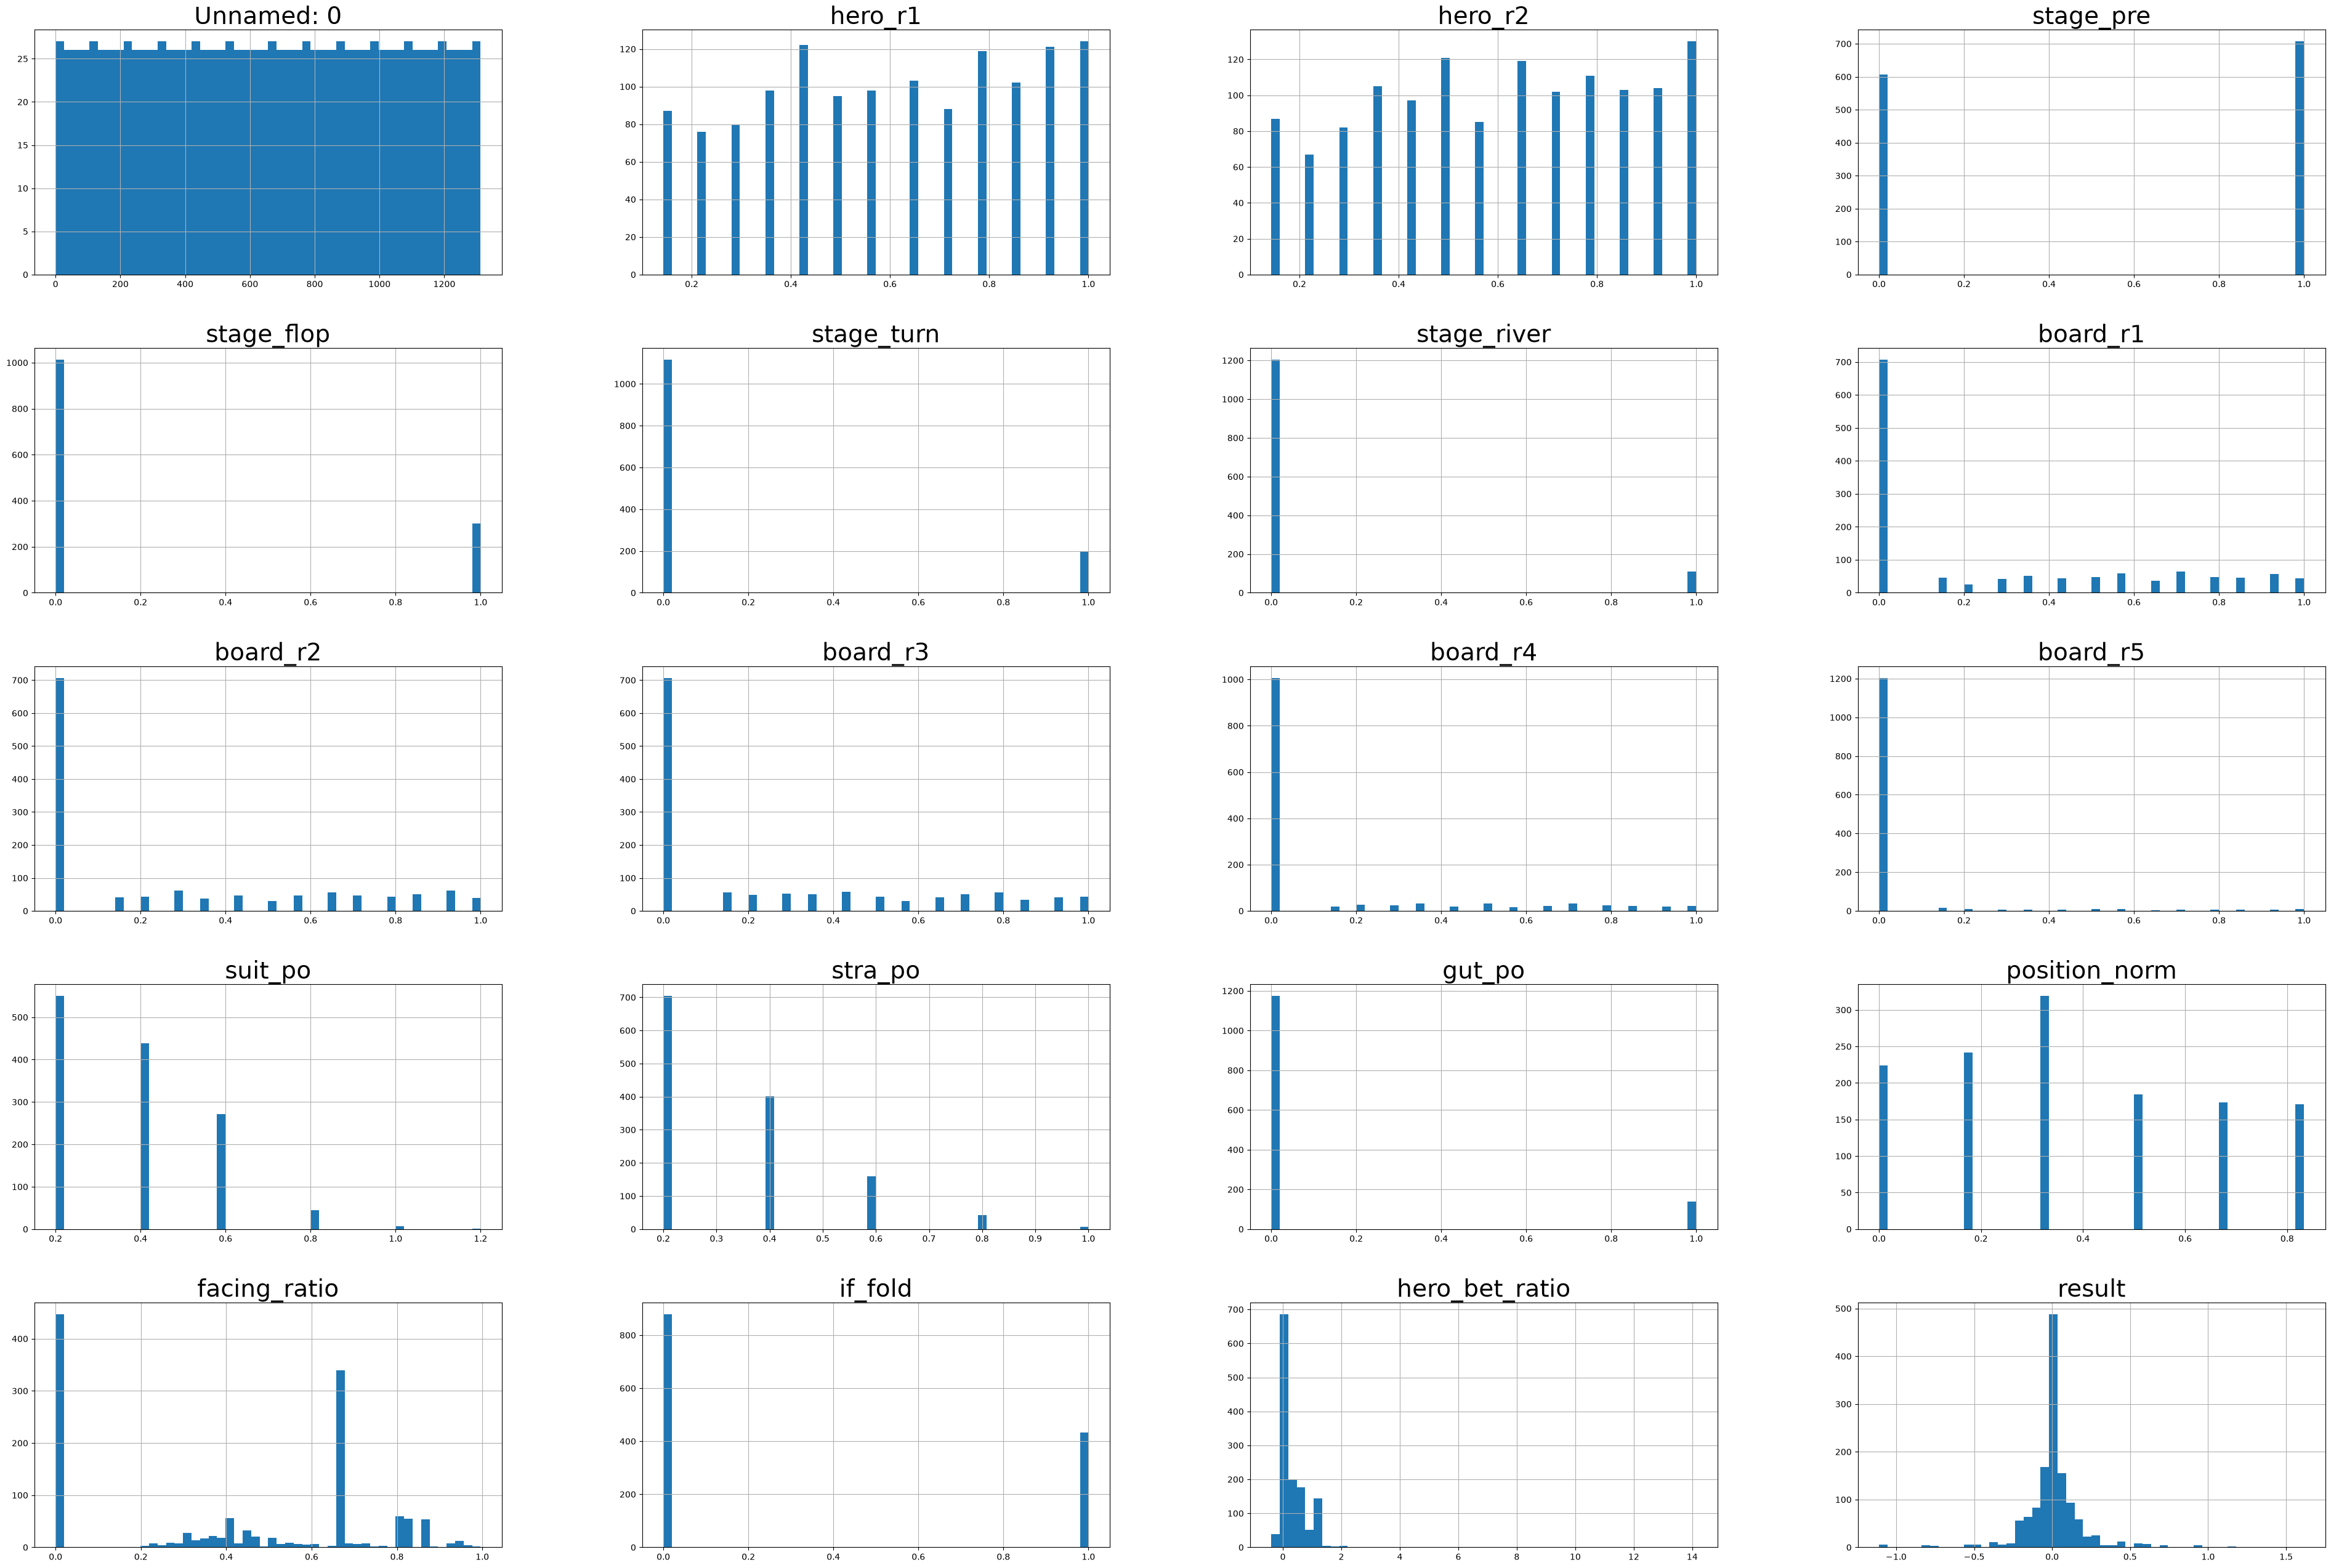

In [19]:
plt.rc('font', size=24)
plt.rc('axes', labelsize=28, titlesize=28)
plt.rc('legend', fontsize=18)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

data.hist(bins=50, figsize=(48, 32))
plt.show()

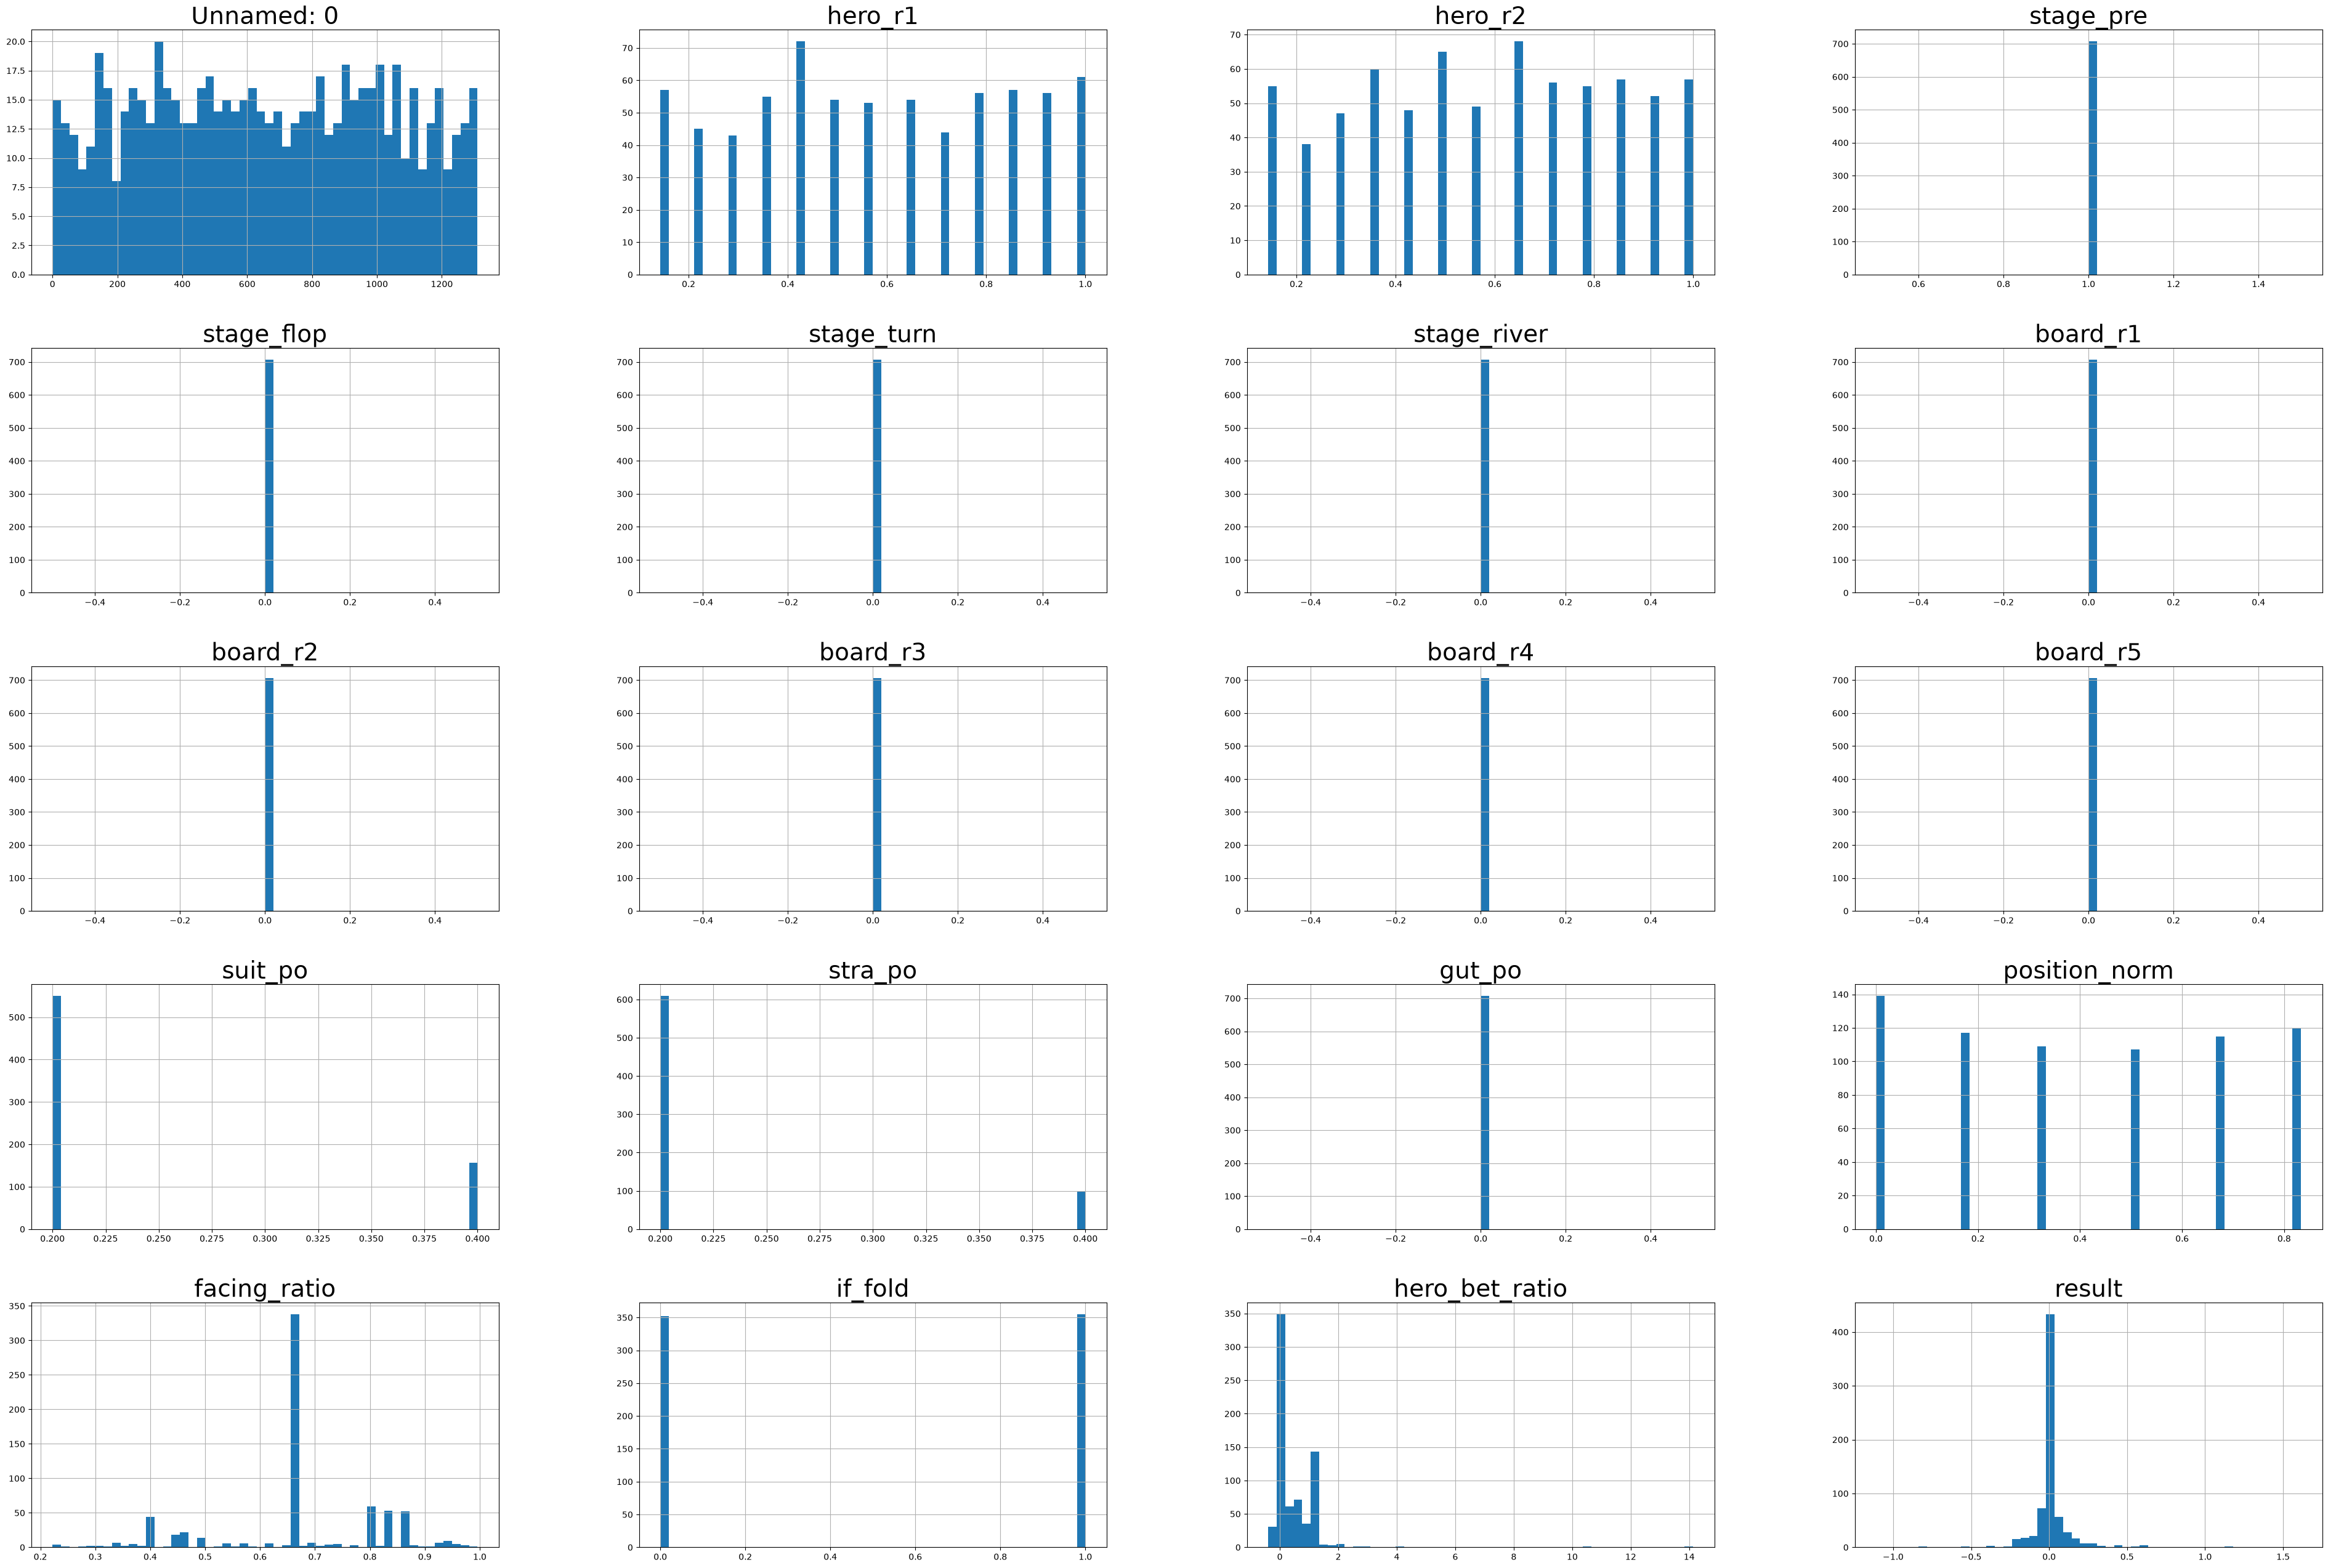

In [23]:
temp = data[data["stage_pre"] == 1]
temp.hist(bins=50, figsize=(48, 32))
plt.show()

In [51]:
temp.loc[temp["facing_ratio"] <= temp["hero_bet_ratio"]]

,Unnamed: 0,hero_r1,hero_r2,stage_pre,stage_flop,stage_turn,stage_river,board_r1,board_r2,board_r3,board_r4,board_r5,suit_po,stra_po,gut_po,position_norm,facing_ratio,if_fold,hero_bet_ratio,action
0,0,0.357,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.167,0.667,0,1.333,2.0
9,9,0.429,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0,0.500,0.667,0,0.667,2.0
12,12,0.571,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0,0.833,0.833,0,0.833,2.0
14,14,0.357,0.571,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.000,0.667,0,1.333,2.0
18,18,0.714,1.000,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.500,0.667,0,1.333,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1252,1252,0.786,1.000,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.2,0,0.000,0.667,0,1.333,2.0
1262,1262,1.000,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.667,0.667,0,0.667,2.0
1264,1264,1.000,0.786,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.2,0,0.833,0.667,0,1.333,2.0
1275,1275,0.857,0.714,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.833,0.667,0,1.333,2.0


In [52]:
temp.loc[temp["if_fold"] == 1, "action"] = 0
temp.loc[(temp["if_fold"] == 0) & (temp["hero_bet_ratio"] == 0), "action"] = 1
temp.loc[(temp["facing_ratio"] <= temp["hero_bet_ratio"]) & (temp["action"] != 0) & (temp["action"] != 1), "action"] = 3
temp.fillna({"action": 2}, inplace=True)
temp["action"].value_counts()

action
0.0    355
3.0    225
2.0    110
1.0     17
Name: count, dtype: int64

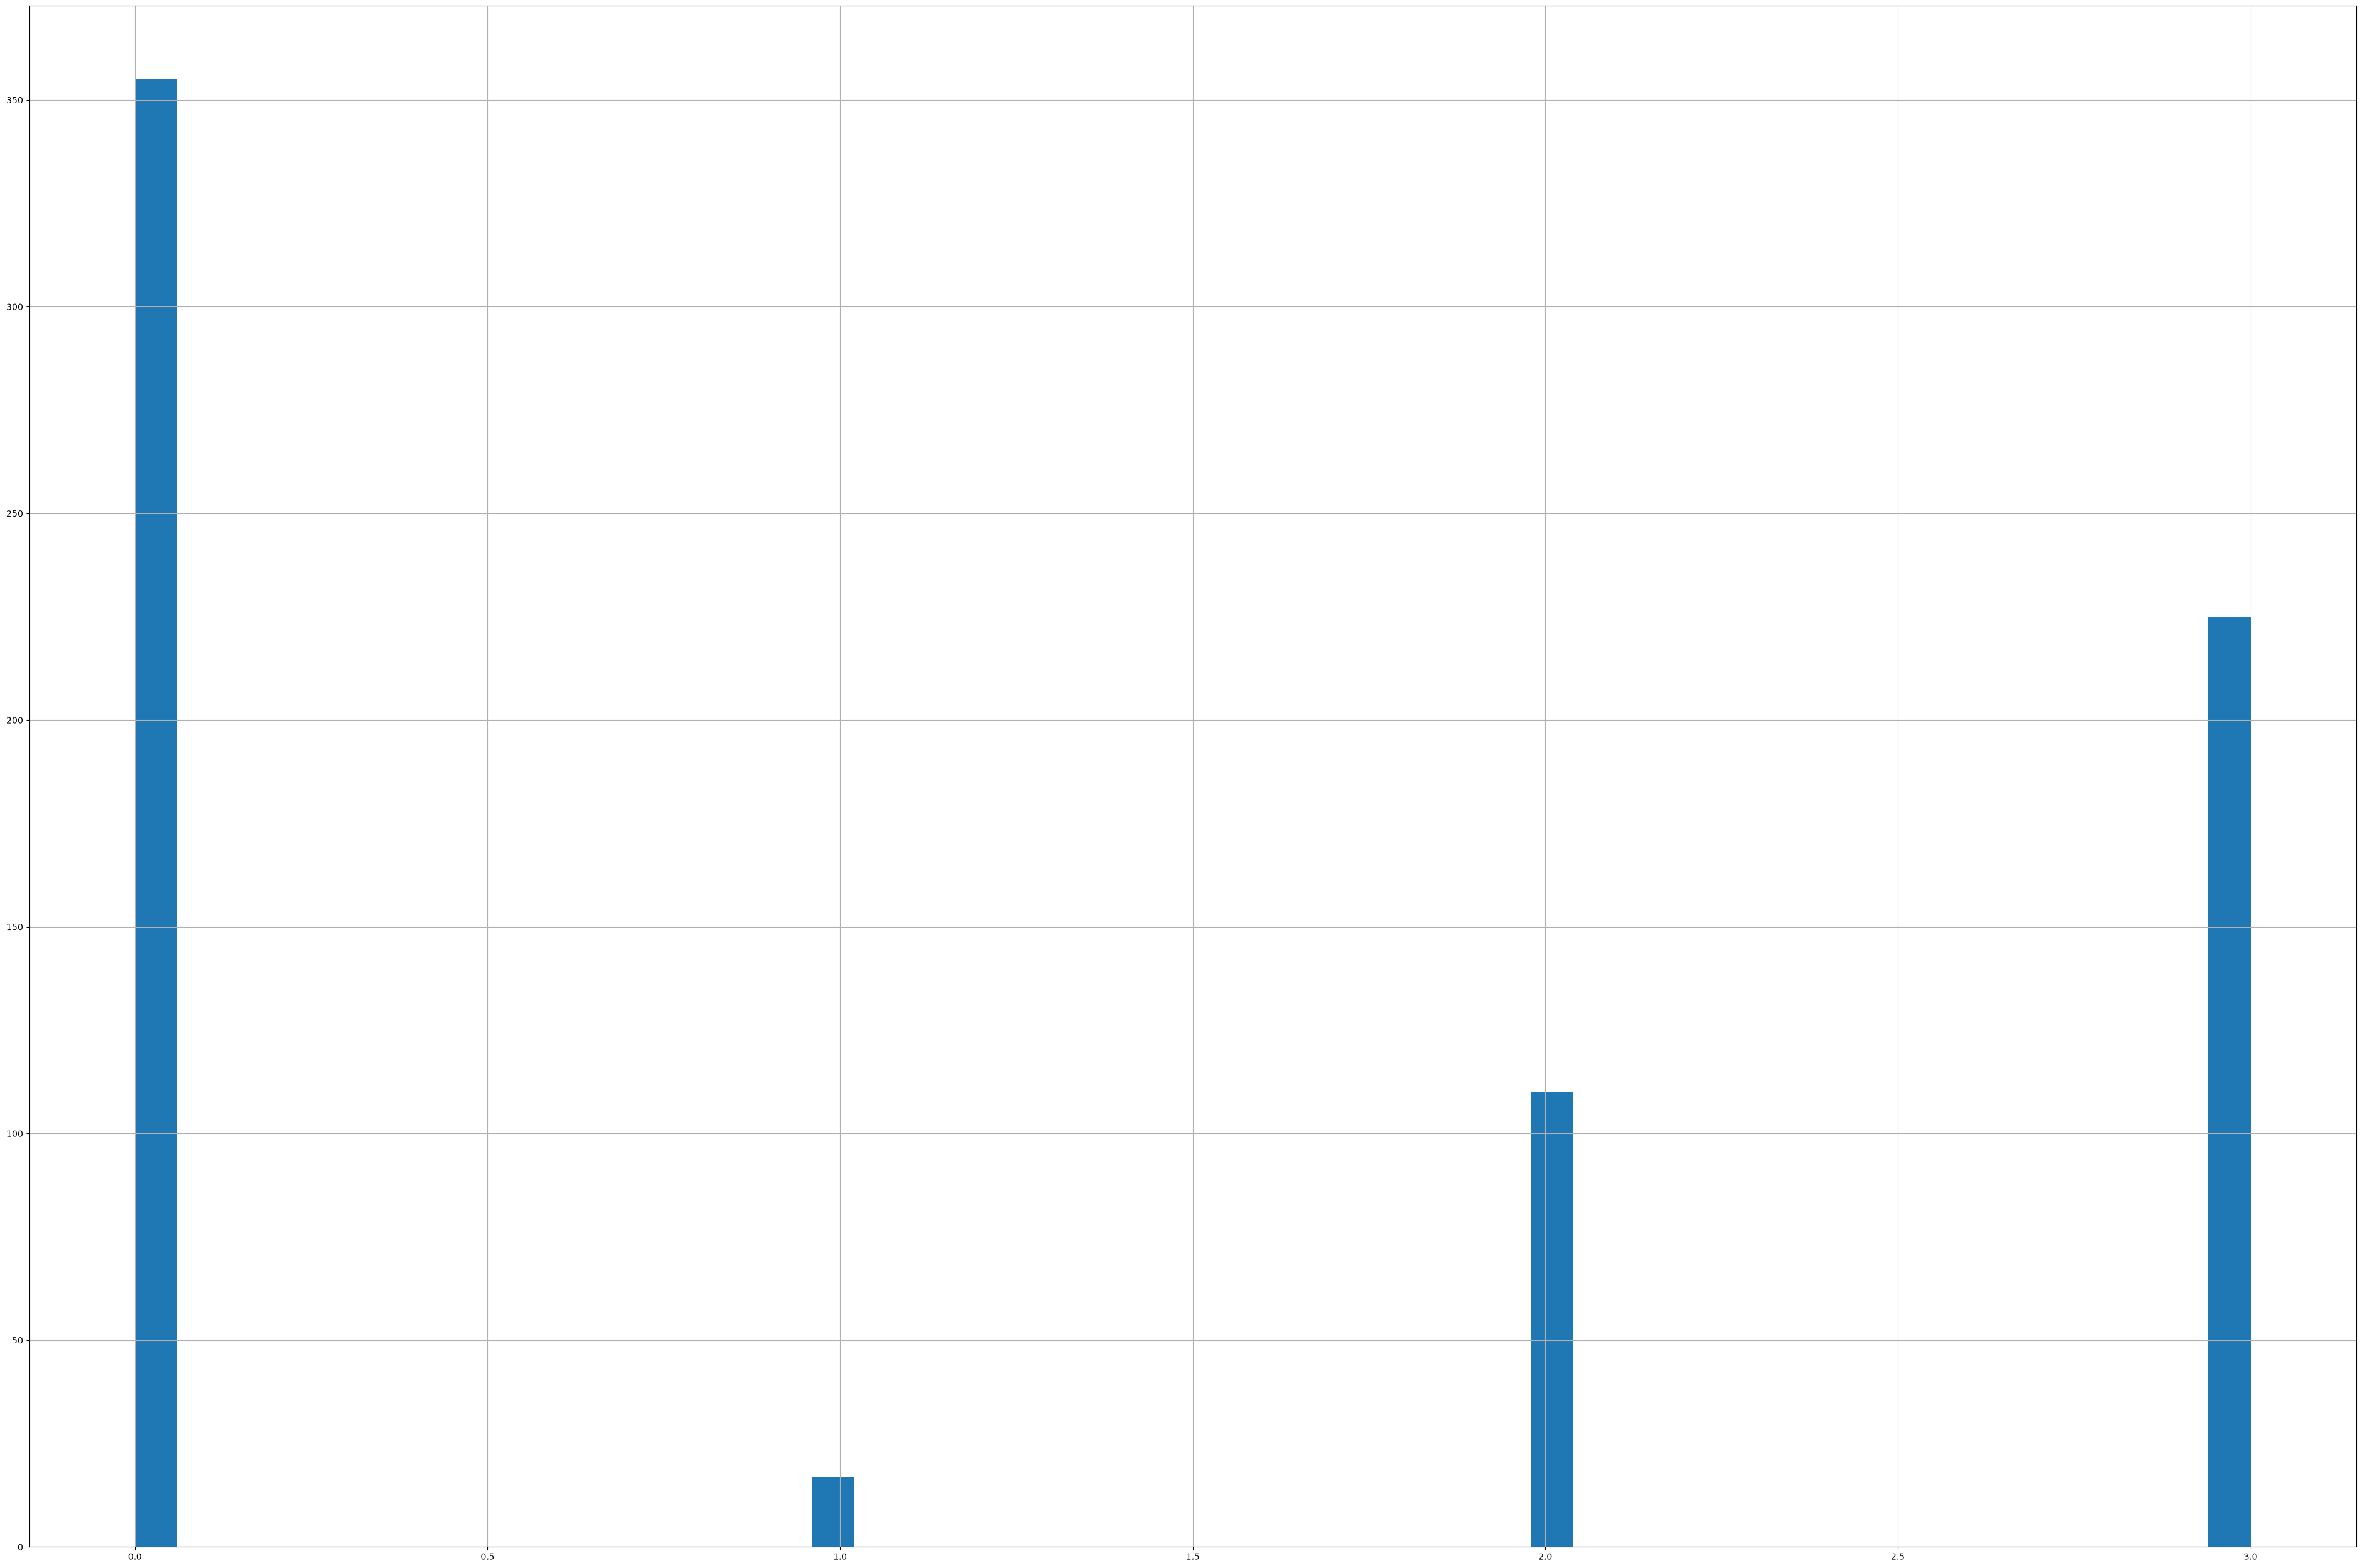

In [53]:
temp["action"].hist(bins=50, figsize=(48, 32))
plt.show()